# Final Model Evaluation

This notebook evaluates the final machine learning model using multiple performance metrics such as Accuracy, Precision, Recall, F1 Score, ROC-AUC, PR Curve, Confusion Matrix, Feature Importance, and Cross Validation Score.

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.model_selection import cross_val_score

best_model = joblib.load("../models/best_model.pkl")
test = pd.read_csv("../data/external/test.csv")
X_test = test.drop('label',axis=1)
y_test = test['label']

## 1. Classification Performance Metrics

Calculate Accuracy, Precision, Recall, F1 Score, and ROC-AUC to evaluate the overall performance of the trained model.

In [24]:
# Predictions
y_pred = best_model.predict(X_test)

# Probability prediction for ROC-AUC and curves
y_prob = best_model.predict_proba(X_test)[:, 1]


# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00     22516

    accuracy                           1.00     22544
   macro avg       1.00      1.00      1.00     22544
weighted avg       1.00      1.00      1.00     22544



## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the classification model.

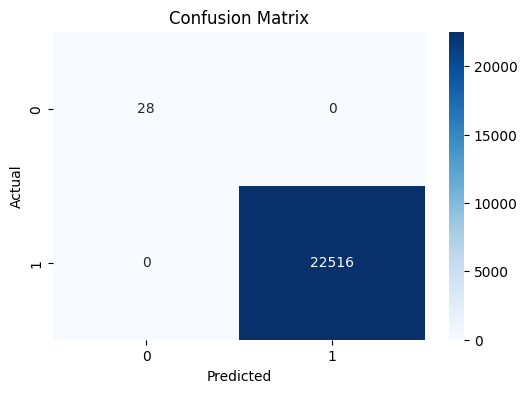

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC Curve

The ROC curve visualizes the trade-off between True Positive Rate and False Positive Rate at different classification thresholds.

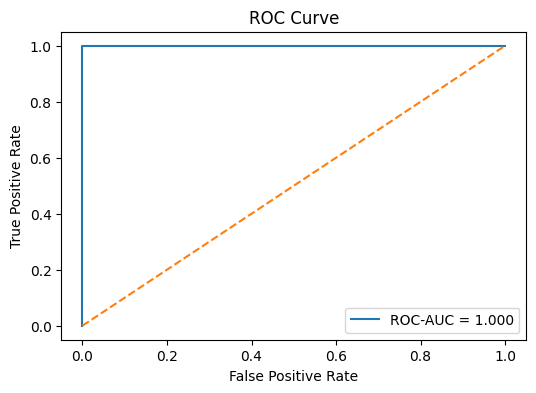

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision Recall Curve

The Precision-Recall curve evaluates model performance, especially when dealing with imbalanced datasets.

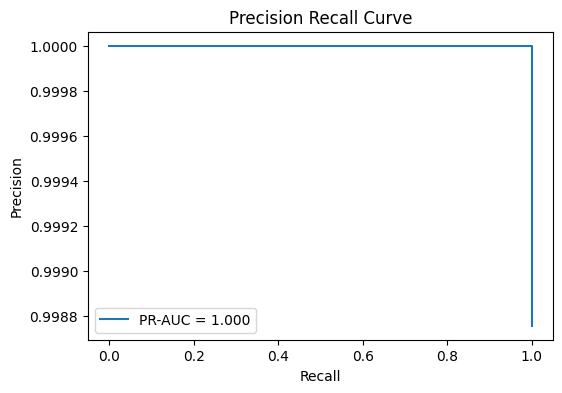

In [27]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(
    recall_values,
    precision_values
)


plt.figure(figsize=(6,4))

plt.plot(
    recall_values,
    precision_values,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()
plt.show()

## Feature Importance

Feature importance identifies the most influential features contributing to the model's predictions.

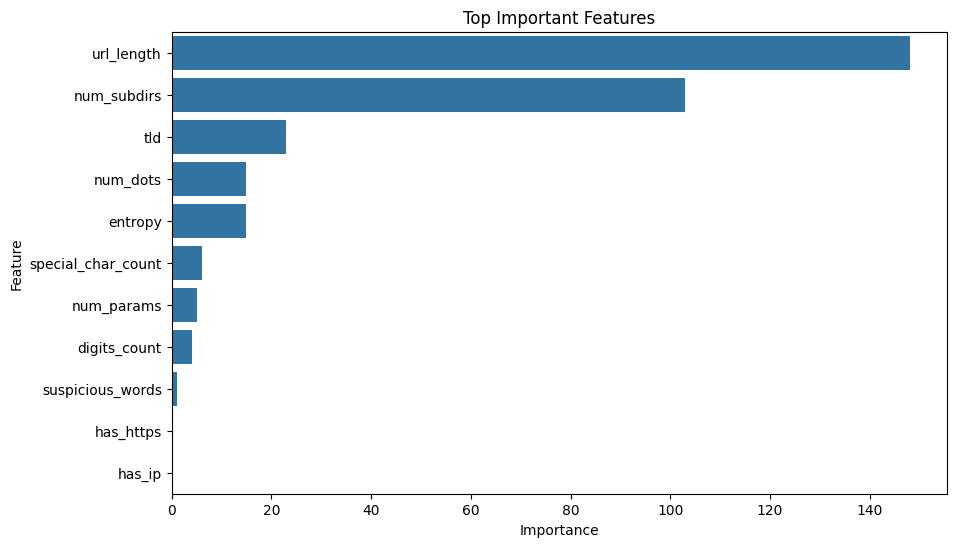

In [29]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": best_model.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Important Features")
plt.show()

## Cross Validation Score

Cross-validation is performed to check the model's stability and generalization ability across different subsets of data.

In [30]:
cv_scores = cross_val_score(
    best_model,
    X_test,
    y_test,
    cv=5,
    scoring="accuracy"
)


print("Cross Validation Scores:")
print(cv_scores)


print("\nMean CV Accuracy:")
print(cv_scores.mean())

[LightGBM] [Info] Number of positive: 18012, number of negative: 23
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 18035, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.998725 -> initscore=6.663299
[LightGBM] [Info] Start training from score 6.663299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

# Final Evaluation Summary

The Random Forest model performance is evaluated using multiple metrics. Accuracy, Precision, Recall, F1 Score, ROC-AUC, PR-AUC, Feature Importance, and Cross Validation provide a complete understanding of model reliability and predictive performance.